# HW Set #2

### Kasia McCoy

##### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astroquery.vizier import Vizier

### 1 - Isochrones

##### 1a Mean distance for Pleiades from Gaia parallax

In [2]:
#Gaia DR3
hdul = fits.open(r"C:\Users\kmcco\Downloads\2026-01-21-03-50-10-505112.fits")
data = hdul[1].data
data_table = Table(data)

In [3]:
p_center = SkyCoord.from_name('Pleiades')

In [4]:
#D (pc)= 1/ pi (arcseconds)
dists = 1/(data_table['parallax'] / 1000)

In [5]:
#M_lambda =  m_lambda + 5 - 5 log(d [pc])
Mags = data_table['phot_g_mean_mag'] + 5 - 5*np.log10(dists)

In [47]:
pm_cond = ((data_table['pmra']<19.997 + 3) & (data_table['pmra']>19.997 -3)) & ((data_table['pmdec']<-45.548 + 3) & (data_table['pmdec']>-45.548 -3))
par_cond = ((data_table['parallax']<7.364 + 1) & (data_table['parallax']>7.364 -1))
ra_cond = (data_table['ra']<p_center.ra.value + 20) & (data_table['ra']>p_center.ra.value -20)
dec_cond = (data_table['dec']<p_center.dec.value + 20) & (data_table['dec']>p_center.dec.value -20)
ple_cond = (pm_cond & par_cond) & (ra_cond & dec_cond) & (data_table['ruwe']< 1.4)
data_table[ple_cond]

source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,ruwe,distance_gspphot,ag_gspphot,ebpminrp_gspphot
int64,float64,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32
3276344921909396736,53.67865424937211,0.013470168,6.843097005918915,0.011098635,7.7273394817762355,0.015265039,506.21155,20.07287781325723,0.016529938,-46.039224668134715,0.014293447,9.434238,0.80709267,0.93833697,128.673,0.0015,0.0008
3297896586765443072,60.50915663143435,0.023946505,7.064302773921485,0.01708349,7.2277062444143265,0.028215352,256.16217,19.336653618722067,0.032647926,-44.536328020953206,0.022992164,14.7766285,2.3885317,1.0956422,136.7069,0.5551,0.3367
3304063708829092480,63.17975130982924,0.1712973,11.554871266445836,0.14229338,8.13241653634523,0.2001527,40.63106,18.770309574019592,0.24094497,-47.63351723040834,0.21255659,18.55179,3.557022,0.88748586,nan,nan,nan
3304256093300474368,62.458149201612564,0.014059549,11.732444720454676,0.009506353,7.71742119911551,0.014769429,522.5267,17.93783980516333,0.019740952,-44.58052096801312,0.013618199,12.41448,1.3870707,1.0468019,129.28,0.1718,0.0905
3306824380664141568,66.28920557934276,0.05026385,11.39878054510752,0.03475082,8.071641545185614,0.05609945,143.88095,19.28938692750502,0.06472983,-45.7282990710713,0.04589665,16.39644,2.938017,0.9762301,124.9095,0.6133,0.407
3307729210014170240,67.0640767240471,0.020235986,13.517150944795082,0.010421092,7.316655108956643,0.023748605,308.0878,20.66939755819959,0.027644781,-45.02470953721446,0.01868275,14.520266,2.2185287,0.9898879,135.7352,0.5262,0.3047
3312208856607630848,63.37346961133951,0.12734985,15.690690420403438,0.09985909,7.737218364251475,0.14070858,54.987537,21.320921037468977,0.18624729,-43.6570449497506,0.16337332,18.050138,3.419714,0.9711785,138.4543,0.7183,0.5136
3312758238760996992,66.60966669820566,0.047942515,15.572226354499007,0.02281141,6.76015483812207,0.056049157,120.611176,22.958576517130567,0.06311944,-47.63721721193136,0.04052586,16.174288,2.6043901,1.0360076,150.2842,0.6302,0.3947
3409145997897791360,76.31623822843538,0.061340727,21.43224001067637,0.03564023,7.184709638290484,0.0638014,112.610535,17.36282559712505,0.07970016,-47.478203671549,0.051114738,16.002756,2.62646,1.3492072,139.1293,0.5105,0.3224


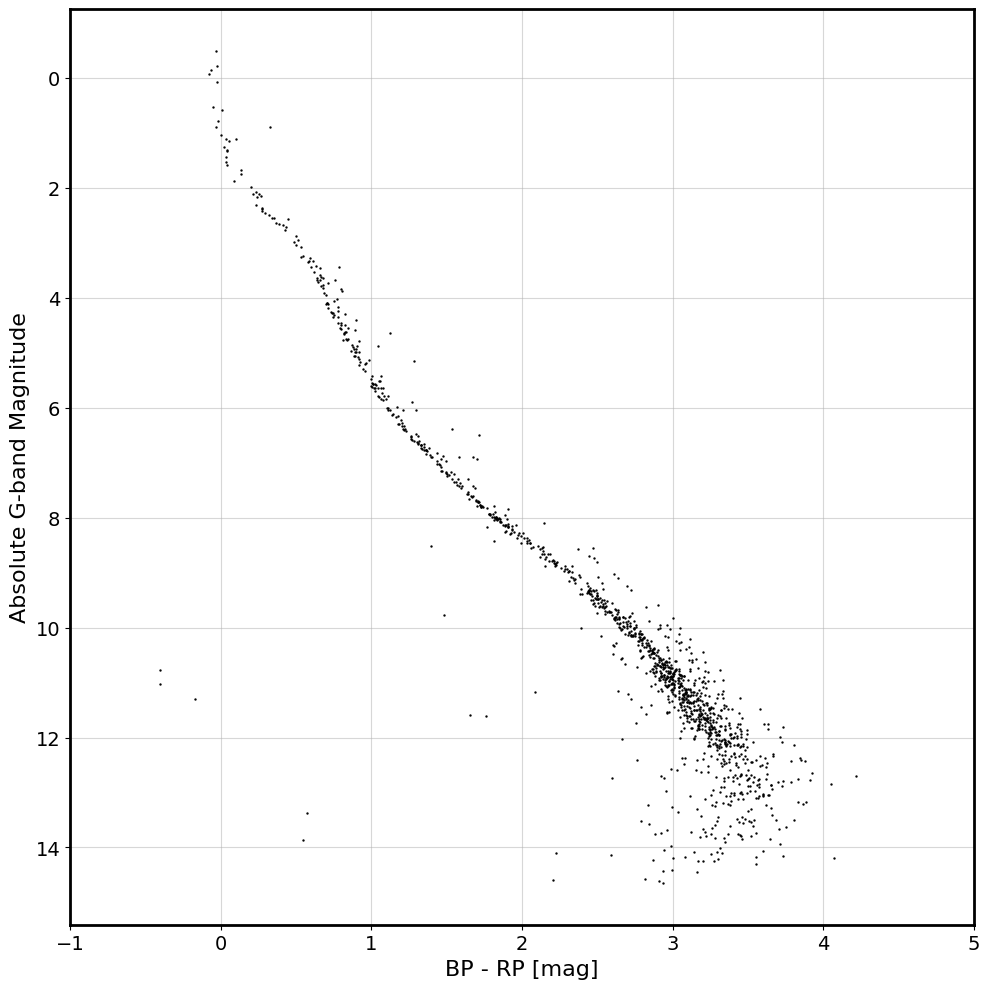

In [48]:
fig,ax = plt.subplots(figsize=(10, 10))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
# colors=['white','khaki','yellow','orange','red']
# for i in range(len(colors)):
#     ax.plot(mj0_bprp[i],mj0_mg[i],linestyle='none',marker='*',color=colors[i],markersize=14,markeredgecolor='black',markeredgewidth=0.7,label=spts_labels[i])

# #Set title, spines, ticks and ticklabels
ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-1,5)
ax.grid(alpha=0.5)

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

In [58]:
print(f'Mean distance for Pleides from Gaia Parallax = {dists[ple_cond].mean():.3f} [pc] +- {dists[ple_cond].std():.3f}')

Mean distance for Pleides from Gaia Parallax = 135.692 [pc] +- 4.791


##### 1b Plot Three Isochrones

In [31]:
import read_mist_models

In [35]:
isocmd = read_mist_models.ISOCMD(r'UBVRIplus\feh_p025_afe_p0_vvcrit0.4_full.iso.UBVRIplus')

Reading in: UBVRIplus\feh_p025_afe_p0_vvcrit0.4_full.iso.UBVRIplus


In [43]:
isocmdp0 = read_mist_models.ISOCMD(r'UBVRIplus\feh_p000_afe_p0_vvcrit0.4_full.iso.UBVRIplus')

Reading in: UBVRIplus\feh_p000_afe_p0_vvcrit0.4_full.iso.UBVRIplus


In [39]:
isocmdv0 = read_mist_models.ISOCMD(r'UBVRIplus\feh_p025_afe_p0_vvcrit0.0_full.iso.UBVRIplus')

Reading in: UBVRIplus\feh_p025_afe_p0_vvcrit0.0_full.iso.UBVRIplus


In [37]:
print('version: ', isocmd.version)
print('photometric system: ', isocmd.photo_sys)
print('abundances: ', isocmd.abun)
print('rotation: ', isocmd.rot)
print('ages: ', [round(x,2) for x in isocmd.ages])
print('number of ages: ', isocmd.num_ages)
print('available columns: ', isocmd.hdr_list)
print('Av extinction: ', isocmd.Av_extinction)

version:  {'MIST': '2.5', 'MESA': '11701'}
photometric system:  UBV(RI)c, 2MASS, Kepler, Hipparcos, Gaia (Vega)
abundances:  {'Yinit': 0.2854, 'Zinit': 0.0279969, '[Fe/H]': 0.25, '[a/Fe]': 0.0}
rotation:  0.4
ages:  [5.0, 5.05, 5.1, 5.15, 5.2, 5.25, 5.3, 5.35, 5.4, 5.45, 5.5, 5.55, 5.6, 5.65, 5.7, 5.75, 5.8, 5.85, 5.9, 5.95, 6.0, 6.05, 6.1, 6.15, 6.2, 6.25, 6.3, 6.35, 6.4, 6.45, 6.5, 6.55, 6.6, 6.65, 6.7, 6.75, 6.8, 6.85, 6.9, 6.95, 7.0, 7.05, 7.1, 7.15, 7.2, 7.25, 7.3, 7.35, 7.4, 7.45, 7.5, 7.55, 7.6, 7.65, 7.7, 7.75, 7.8, 7.85, 7.9, 7.95, 8.0, 8.05, 8.1, 8.15, 8.2, 8.25, 8.3, 8.35, 8.4, 8.45, 8.5, 8.55, 8.6, 8.65, 8.7, 8.75, 8.8, 8.85, 8.9, 8.95, 9.0, 9.05, 9.1, 9.15, 9.2, 9.25, 9.3, 9.35, 9.4, 9.45, 9.5, 9.55, 9.6, 9.65, 9.7, 9.75, 9.8, 9.85, 9.9, 9.95, 10.0, 10.05, 10.1, 10.15, 10.2, 10.25, 10.3]
number of ages:  107
available columns:  ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff', 'log_R', 'log_g', 'log_L', '[Fe/H]_init', '[Fe/H]', 'Bessell_U', 'Bessel

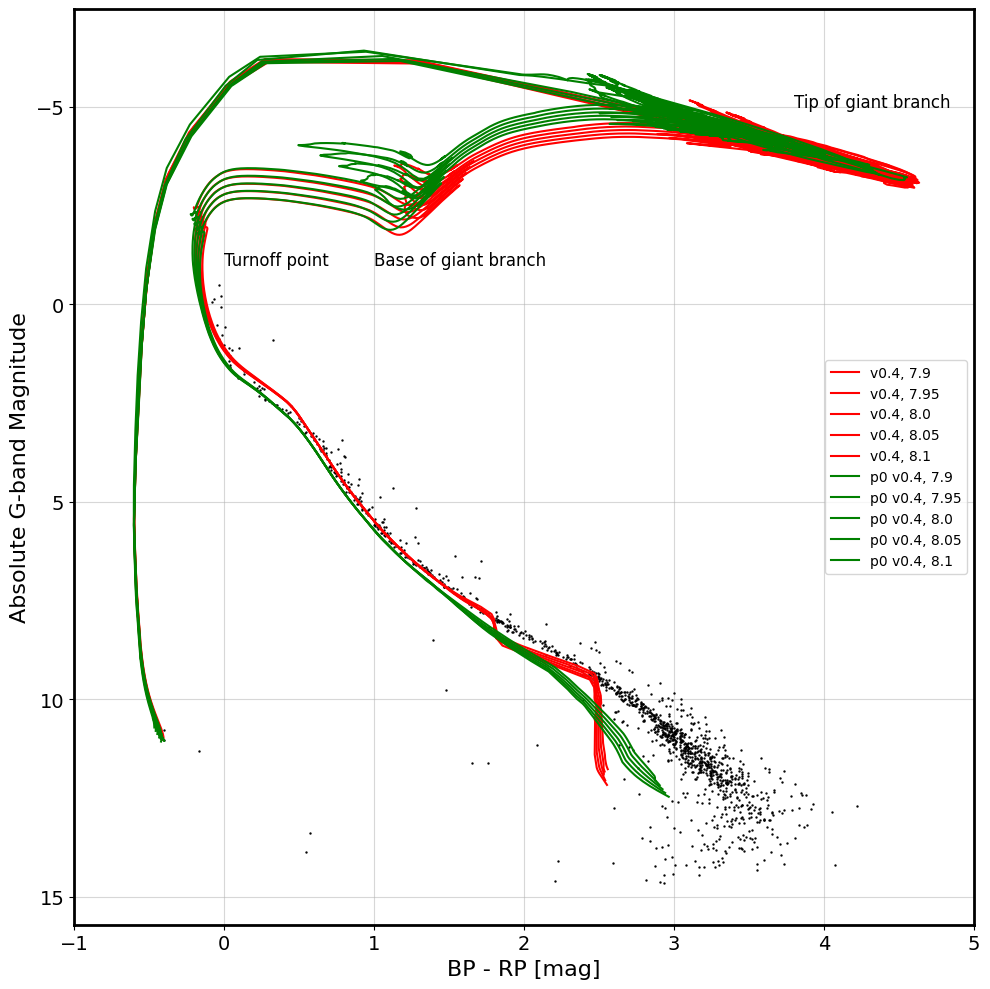

In [56]:
fig,ax = plt.subplots(figsize=(10, 10))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
ages = [7.9,7.95,8.0,8.05,8.1]
for i in ages:
    age_ind = isocmd.age_index(i) #returns the index for the desired age
    G_mag = isocmd.isocmds[age_ind]['Gaia_G_EDR3']
    BPG = isocmd.isocmds[age_ind]['Gaia_BP_EDR3']
    RPG = isocmd.isocmds[age_ind]['Gaia_RP_EDR3']
    ax.plot(BPG-RPG,G_mag,label='v0.4, '+str(i),color='red')

ages = [7.9,7.95,8.0,8.05,8.1]
for i in ages:
    age_ind = isocmdp0.age_index(i) #returns the index for the desired age
    G_mag = isocmdp0.isocmds[age_ind]['Gaia_G_EDR3']
    BPG = isocmdp0.isocmds[age_ind]['Gaia_BP_EDR3']
    RPG = isocmdp0.isocmds[age_ind]['Gaia_RP_EDR3']
    ax.plot(BPG-RPG,G_mag,label='p0 v0.4, '+str(i),color='green')

# ages = [7.9,7.95,8.0,8.05,8.1]
# for i in ages:
#     age_ind = isocmdv0.age_index(i) #returns the index for the desired age
#     G_mag = isocmdv0.isocmds[age_ind]['Gaia_G_EDR3']
#     BPG = isocmdv0.isocmds[age_ind]['Gaia_BP_EDR3']
#     RPG = isocmdv0.isocmds[age_ind]['Gaia_RP_EDR3']
#     ax.plot(BPG-RPG,G_mag,label='v0.0, '+str(i)) 
# colors=['white','khaki','yellow','orange','red']
# for i in range(len(colors)):
#     ax.plot(mj0_bprp[i],mj0_mg[i],linestyle='none',marker='*',color=colors[i],markersize=14,markeredgecolor='black',markeredgewidth=0.7,label=spts_labels[i])

# #Set title, spines, ticks and ticklabels

ax.text(x=0,y=-1,s='Turnoff point',fontsize=12)
ax.text(x=1,y=-1,s='Base of giant branch',fontsize=12)
ax.text(x=3.8,y=-5,s='Tip of giant branch',fontsize=12)

ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-1,5)
ax.grid(alpha=0.5)
ax.legend()

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

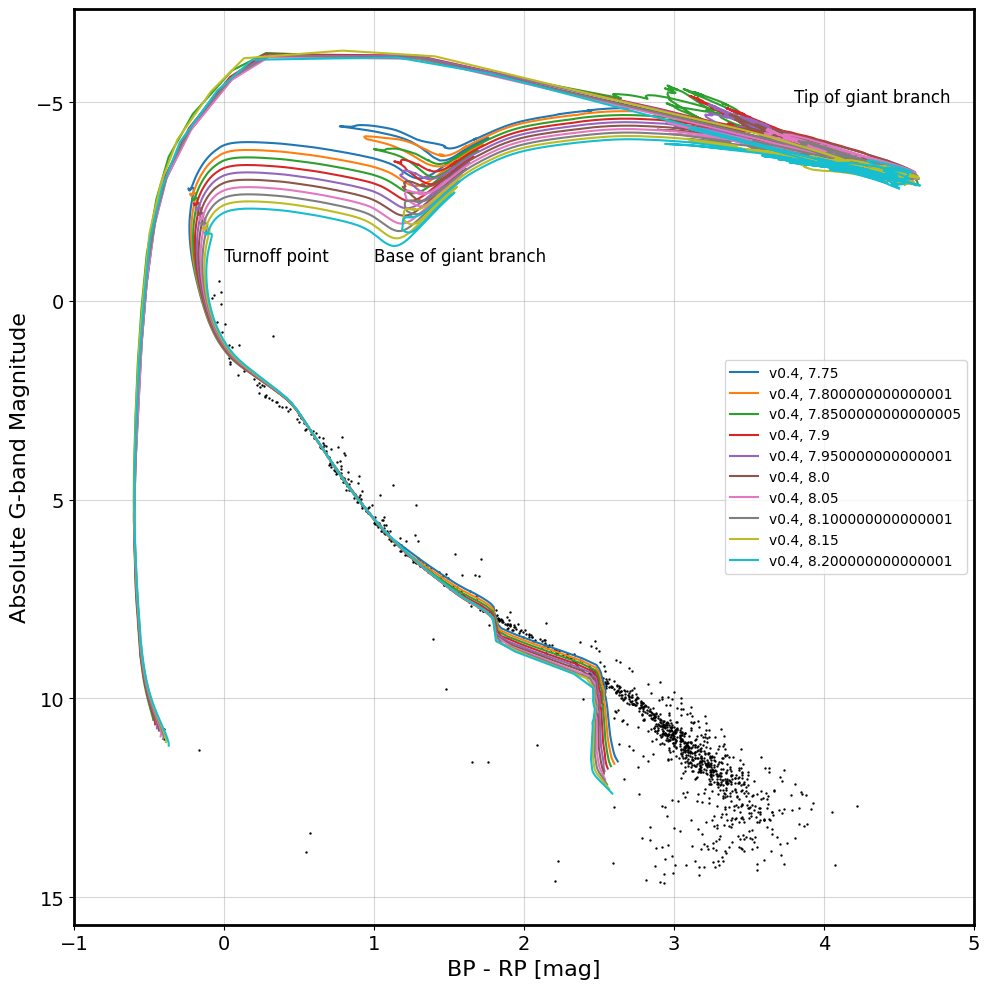

In [70]:
fig,ax = plt.subplots(figsize=(10, 10))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
count =0
for i in isocmd.ages[55:65]:
    age_ind = isocmd.age_index(i) #returns the index for the desired age
    G_mag = isocmd.isocmds[age_ind]['Gaia_G_EDR3']
    BPG = isocmd.isocmds[age_ind]['Gaia_BP_EDR3']
    RPG = isocmd.isocmds[age_ind]['Gaia_RP_EDR3']
    ax.plot(BPG-RPG,G_mag,label='v0.4, '+str(i))
    count +=1
    if count==20:
        break

# ages = [7.9,7.95,8.0,8.05,8.1]
# for i in ages:
#     age_ind = isocmd.age_index(i) #returns the index for the desired age
#     G_mag = isocmd.isocmds[age_ind]['Gaia_G_EDR3']
#     BPG = isocmd.isocmds[age_ind]['Gaia_BP_EDR3']
#     RPG = isocmd.isocmds[age_ind]['Gaia_RP_EDR3']
#     ax.plot(BPG-RPG,G_mag,label='v0.4, '+str(i),color='red')

# ages = [7.9,7.95,8.0,8.05,8.1]
# for i in ages:
#     age_ind = isocmdp0.age_index(i) #returns the index for the desired age
#     G_mag = isocmdp0.isocmds[age_ind]['Gaia_G_EDR3']
#     BPG = isocmdp0.isocmds[age_ind]['Gaia_BP_EDR3']
#     RPG = isocmdp0.isocmds[age_ind]['Gaia_RP_EDR3']
#     ax.plot(BPG-RPG,G_mag,label='p0 v0.4, '+str(i),color='green')

# ages = [7.9,7.95,8.0,8.05,8.1]
# for i in ages:
#     age_ind = isocmdv0.age_index(i) #returns the index for the desired age
#     G_mag = isocmdv0.isocmds[age_ind]['Gaia_G_EDR3']
#     BPG = isocmdv0.isocmds[age_ind]['Gaia_BP_EDR3']
#     RPG = isocmdv0.isocmds[age_ind]['Gaia_RP_EDR3']
#     ax.plot(BPG-RPG,G_mag,label='v0.0, '+str(i)) 
# colors=['white','khaki','yellow','orange','red']
# for i in range(len(colors)):
#     ax.plot(mj0_bprp[i],mj0_mg[i],linestyle='none',marker='*',color=colors[i],markersize=14,markeredgecolor='black',markeredgewidth=0.7,label=spts_labels[i])

# #Set title, spines, ticks and ticklabels

ax.text(x=0,y=-1,s='Turnoff point',fontsize=12)
ax.text(x=1,y=-1,s='Base of giant branch',fontsize=12)
ax.text(x=3.8,y=-5,s='Tip of giant branch',fontsize=12)

ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-1,5)
ax.grid(alpha=0.5)
ax.legend()

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

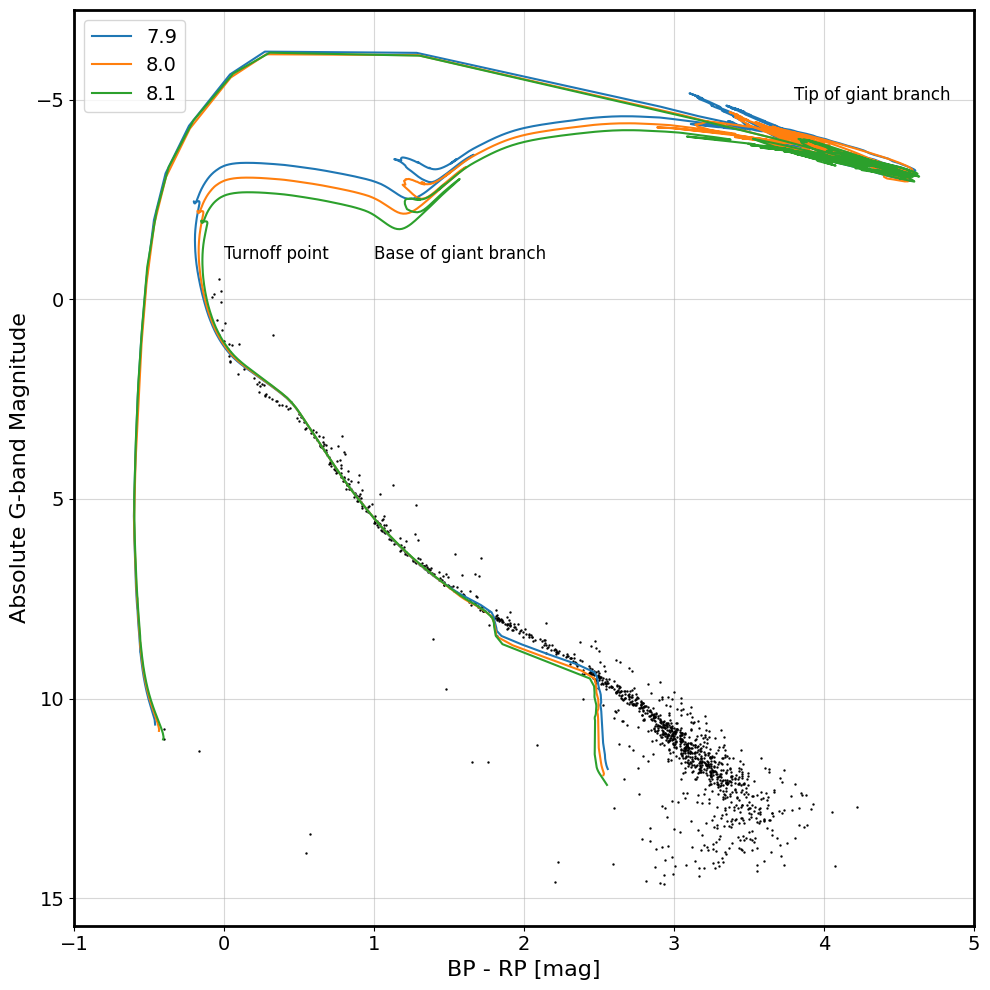

In [73]:
fig,ax = plt.subplots(figsize=(10, 10))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
ages = [7.9,8.0,8.1]
for i in ages:
    age_ind = isocmd.age_index(i) #returns the index for the desired age
    G_mag = isocmd.isocmds[age_ind]['Gaia_G_EDR3']
    BPG = isocmd.isocmds[age_ind]['Gaia_BP_EDR3']
    RPG = isocmd.isocmds[age_ind]['Gaia_RP_EDR3']
    ax.plot(BPG-RPG,G_mag,label=str(i))

# #Set title, spines, ticks and ticklabels

ax.text(x=0,y=-1,s='Turnoff point',fontsize=12)
ax.text(x=1,y=-1,s='Base of giant branch',fontsize=12)
ax.text(x=3.8,y=-5,s='Tip of giant branch',fontsize=12)

ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-1,5)
ax.grid(alpha=0.5)
ax.legend(fontsize=14)

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

##### 1c Tabulate, K-H, nuc timescales

In [ ]:
#t_KH = GM^2 / RL
#t_nuc = 0.007 M c^2 / L

##### 1d MIST evolution track